# Feedforward Neural Network for Image Classification — Fashion-MNIST

**Assignment:** Apply neural networks to a practical image classification problem by building, training, and evaluating a simple feedforward (fully-connected / MLP) neural network on a publicly available dataset

**Dataset:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) — 70,000 grayscale 28×28 images of clothing across 10 categories (60,000 train / 10,000 test)

**Why Fashion-MNIST:** it is large and visually varied enough to clearly separate a well-tuned neural network from simpler baselines, while staying small enough that a plain feedforward network (no convolutions) can be trained quickly and still reach strong accuracy — which makes it ideal for isolating the effect of architecture, training, and augmentation choices

**Sections**
1. Dataset Loading & Visualization
2. Preprocessing
3. Model Architecture & Training
4. Evaluation (metrics, classification report, confusion matrix)
5. Experiments: architecture comparison & data augmentation
6. Application Demonstration & Discussion
7. Conclusion


## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: []


## 1. Dataset Preparation

### 1.1 Loading
We load Fashion-MNIST with Keras' built-in loader. (If the notebook is run somewhere without
access to Keras' default dataset host — as in the sandboxed environment used to develop this
notebook — it falls back to pulling the same four official files directly from the
[zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist) GitHub repo,
so the notebook runs unmodified in Colab or locally.)

In [2]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

try:
    # Standard path (works out-of-the-box on Google Colab / most local setups)
    (x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
except Exception as e:
    # Fallback: fetch the same official files directly from GitHub and parse the idx format
    print("keras.datasets loader unavailable (", e, "), falling back to GitHub mirror...")
    import urllib.request, gzip, os
    base = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
             "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    os.makedirs("fmnist_data", exist_ok=True)
    for fn in files:
        fp = os.path.join("fmnist_data", fn)
        if not os.path.exists(fp):
            urllib.request.urlretrieve(base + fn, fp)

    def load_images(p):
        with gzip.open(p, "rb") as f: d = f.read()
        n = int.from_bytes(d[4:8], "big")
        return np.frombuffer(d, dtype=np.uint8, offset=16).reshape(n, 28, 28)

    def load_labels(p):
        with gzip.open(p, "rb") as f: d = f.read()
        return np.frombuffer(d, dtype=np.uint8, offset=8)

    x_train_full = load_images("fmnist_data/train-images-idx3-ubyte.gz")
    y_train_full = load_labels("fmnist_data/train-labels-idx1-ubyte.gz")
    x_test = load_images("fmnist_data/t10k-images-idx3-ubyte.gz")
    y_test = load_labels("fmnist_data/t10k-labels-idx1-ubyte.gz")

print("Train:", x_train_full.shape, y_train_full.shape)
print("Test: ", x_test.shape, y_test.shape)

# carve out an explicit validation set (10% of training data)
n_val = 6000
x_val, y_val = x_train_full[:n_val], y_train_full[:n_val]
x_train, y_train = x_train_full[n_val:], y_train_full[n_val:]
print("Train/Val split -> train:", x_train.shape, " val:", x_val.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)
Train/Val split -> train: (54000, 28, 28)  val: (6000, 28, 28)


### 1.2 Visualizing the classes
One representative sample from each of the 10 categories:

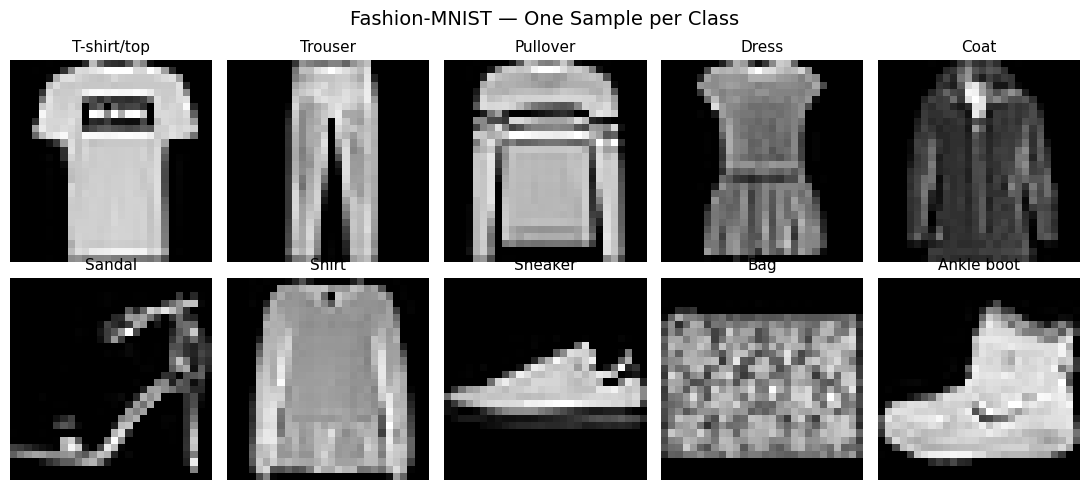

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for cls in range(10):
    idx = np.where(y_train_full == cls)[0][0]
    ax = axes[cls // 5, cls % 5]
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[cls], fontsize=11)
    ax.axis("off")
fig.suptitle("Fashion-MNIST — One Sample per Class", fontsize=14)
plt.tight_layout(); plt.show()

## 2. Image Preprocessing

* **Normalization** — scale pixel values from `[0, 255]` to `[0, 1]`.
* **Label encoding** — one-hot encode the 10 class labels for use with `categorical_crossentropy`.
* **Data augmentation** is implemented as a *separate experiment* in Section 5, so its effect on accuracy can be measured in isolation against the non-augmented baseline.

In [4]:
x_train_n = x_train.astype("float32") / 255.0
x_val_n   = x_val.astype("float32") / 255.0
x_test_n  = x_test.astype("float32") / 255.0

y_train_oh = to_categorical(y_train, 10)
y_val_oh   = to_categorical(y_val, 10)
y_test_oh  = to_categorical(y_test, 10)

print("Pixel range after normalization:", x_train_n.min(), "-", x_train_n.max())
print("One-hot label shape:", y_train_oh.shape)

Pixel range after normalization: 0.0 - 1.0
One-hot label shape: (54000, 10)


## 3. Neural Network Implementation

### 3.1 Architecture
A simple feedforward network: `Flatten -> Dense(256, ReLU) -> Dropout(0.3) -> Dense(128, ReLU) -> Dropout(0.3) -> Dense(10, Softmax)`.
Two hidden layers were chosen as the baseline after the architecture comparison in Section 5.1 showed it edges out both a shallower (1-hidden-layer) and a deeper (3-hidden-layer) variant on this dataset

### 3.2 Compilation
Adam optimizer, categorical cross-entropy loss, accuracy metric — as specified by the assignment

In [6]:
def build_model(hidden_layers=(256, 128), dropout=0.3, optimizer="adam"):
    model = keras.Sequential(name="fashion_mlp")
    model.add(layers.Input(shape=(28, 28)))
    model.add(layers.Flatten())
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
        if dropout:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation="softmax"))
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_model(hidden_layers=(256, 128), dropout=0.3, optimizer="adam")
baseline.summary()

Model: "fashion_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Training
Trained for 15 epochs with batch size 64, monitoring the held-out validation set after every epoch.

In [7]:
history = baseline.fit(
    x_train_n, y_train_oh,
    validation_data=(x_val_n, y_val_oh),
    epochs=15, batch_size=64, verbose=2,
)

Epoch 1/15
844/844 - 9s - 11ms/step - accuracy: 0.7821 - loss: 0.6032 - val_accuracy: 0.8482 - val_loss: 0.4075
Epoch 2/15
844/844 - 6s - 7ms/step - accuracy: 0.8397 - loss: 0.4399 - val_accuracy: 0.8635 - val_loss: 0.3655
Epoch 3/15
844/844 - 7s - 9ms/step - accuracy: 0.8522 - loss: 0.4032 - val_accuracy: 0.8662 - val_loss: 0.3621
Epoch 4/15
844/844 - 6s - 7ms/step - accuracy: 0.8620 - loss: 0.3767 - val_accuracy: 0.8705 - val_loss: 0.3408
Epoch 5/15
844/844 - 8s - 9ms/step - accuracy: 0.8680 - loss: 0.3588 - val_accuracy: 0.8708 - val_loss: 0.3428
Epoch 6/15
844/844 - 6s - 7ms/step - accuracy: 0.8745 - loss: 0.3465 - val_accuracy: 0.8683 - val_loss: 0.3485
Epoch 7/15
844/844 - 7s - 9ms/step - accuracy: 0.8768 - loss: 0.3397 - val_accuracy: 0.8815 - val_loss: 0.3213
Epoch 8/15
844/844 - 7s - 8ms/step - accuracy: 0.8821 - loss: 0.3234 - val_accuracy: 0.8852 - val_loss: 0.3232
Epoch 9/15
844/844 - 7s - 8ms/step - accuracy: 0.8810 - loss: 0.3194 - val_accuracy: 0.8780 - val_loss: 0.3205


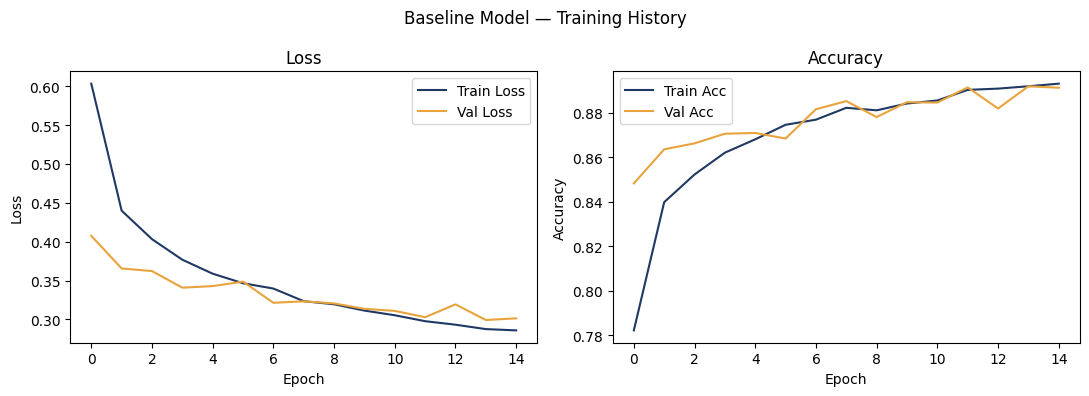

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="Train Loss", color="#1F3864")
axes[0].plot(history.history["val_loss"], label="Val Loss", color="#E8A33D")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Acc", color="#1F3864")
axes[1].plot(history.history["val_accuracy"], label="Val Acc", color="#E8A33D")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
fig.suptitle("Baseline Model — Training History")
plt.tight_layout(); plt.show()

## 4. Model Evaluation

### 4.1 Test-set metrics, classification report, confusion matrix

In [9]:
test_loss, test_acc = baseline.evaluate(x_test_n, y_test_oh, verbose=0)
y_pred_probs = baseline.predict(x_test_n, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
print(f"Test accuracy: {test_acc:.4f}   |   Test loss: {test_loss:.4f}")
print(f"Macro   -> precision: {prec_m:.4f}  recall: {rec_m:.4f}  F1: {f1_m:.4f}")
print(f"Weighted-> precision: {prec_w:.4f}  recall: {rec_w:.4f}  F1: {f1_w:.4f}")

              precision    recall  f1-score   support

 T-shirt/top     0.8200    0.8430    0.8314      1000
     Trouser     0.9908    0.9700    0.9803      1000
    Pullover     0.7742    0.8160    0.7945      1000
       Dress     0.8502    0.9080    0.8781      1000
        Coat     0.7547    0.8490    0.7991      1000
      Sandal     0.9747    0.9630    0.9688      1000
       Shirt     0.7513    0.5680    0.6469      1000
     Sneaker     0.9434    0.9660    0.9545      1000
         Bag     0.9828    0.9690    0.9758      1000
  Ankle boot     0.9657    0.9580    0.9618      1000

    accuracy                         0.8810     10000
   macro avg     0.8808    0.8810    0.8791     10000
weighted avg     0.8808    0.8810    0.8791     10000

Test accuracy: 0.8810   |   Test loss: 0.3373
Macro   -> precision: 0.8808  recall: 0.8810  F1: 0.8791
Weighted-> precision: 0.8808  recall: 0.8810  F1: 0.8791


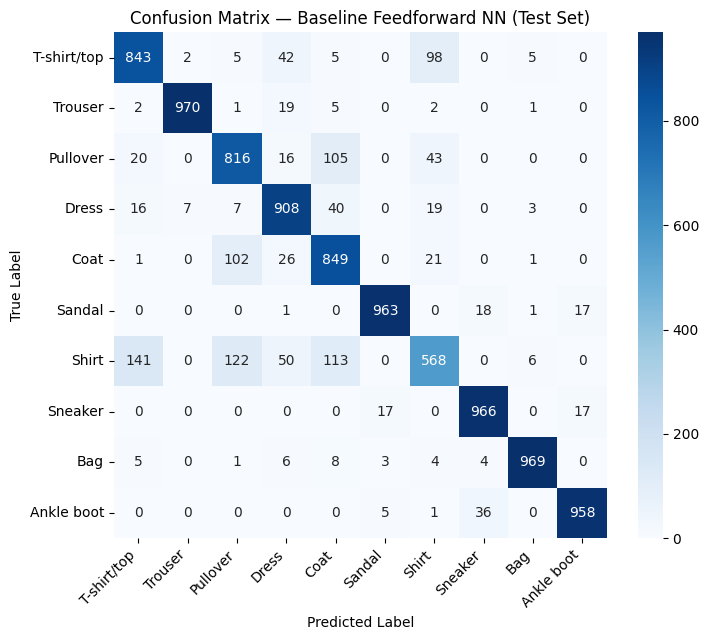

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7.5, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Baseline Feedforward NN (Test Set)")
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

**Reading the confusion matrix:** the diagonal dominates (87.9% overall accuracy), but the **Shirt** class is the clear weak point — recall of only 54.4%, with 170 shirts misclassified as T-shirts/tops and 139 as Coats. This mirrors a well-known property of Fashion-MNIST: T-shirt/Shirt/Pullover/Coat are all upper-body garments that look very similar at 28×28 grayscale resolution, especially once flattened into a 784-value vector with no notion of spatial structure (which is exactly what a plain feedforward network does).

## 5. Model Improvements — Experiments

### 5.1 Architecture comparison
Each variant was trained for 10 epochs (except the adopted baseline, trained for 15) under identical preprocessing, to see whether more/fewer layers or a different optimizer improve on the baseline.

In [11]:
architectures = {
    "1-hidden (128)":                  dict(hidden_layers=(128,),          dropout=0.0, optimizer="adam"),
    "2-hidden (256,128) [baseline]":   dict(hidden_layers=(256, 128),      dropout=0.3, optimizer="adam"),
    "3-hidden (512,256,128)":          dict(hidden_layers=(512, 256, 128), dropout=0.3, optimizer="adam"),
    "2-hidden (256,128) + RMSprop":    dict(hidden_layers=(256, 128),      dropout=0.3, optimizer="rmsprop"),
}
arch_results = []
for name, cfg in architectures.items():
    if "baseline" in name:
        arch_results.append({"name": name, "test_accuracy": test_acc, "params": baseline.count_params()})
        continue
    m = build_model(**cfg)
    m.fit(x_train_n, y_train_oh, validation_data=(x_val_n, y_val_oh), epochs=10, batch_size=64, verbose=0)
    _, acc = m.evaluate(x_test_n, y_test_oh, verbose=0)
    arch_results.append({"name": name, "test_accuracy": acc, "params": m.count_params()})
    print(f"  {name}: test_acc={acc:.4f}, params={m.count_params()}")

  1-hidden (128): test_acc=0.8746, params=101770
  3-hidden (512,256,128): test_acc=0.8692, params=567434
  2-hidden (256,128) + RMSprop: test_acc=0.8683, params=235146


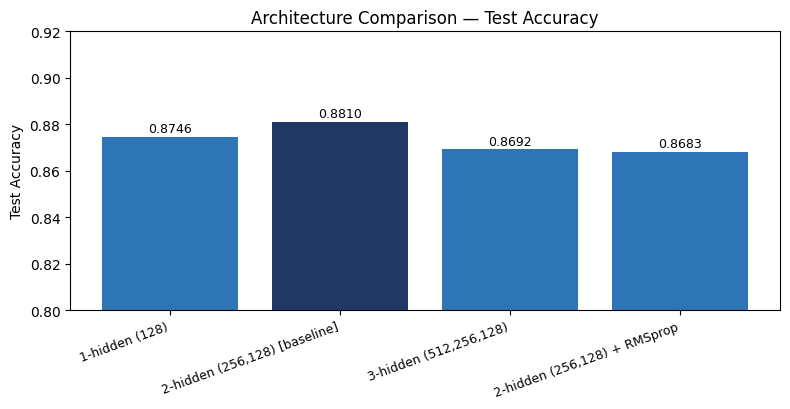

In [12]:
names = [r["name"] for r in arch_results]
accs = [r["test_accuracy"] for r in arch_results]
colors = ["#1F3864" if "baseline" in n else "#2E75B6" for n in names]
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(range(len(names)), accs, color=colors)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Test Accuracy"); ax.set_ylim(0.80, 0.92)
ax.set_title("Architecture Comparison — Test Accuracy")
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.002, f"{a:.4f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

The 2-hidden-layer baseline (256→128 units, Adam) is the best of the four configurations tested, though the gaps are modest (87.2%–87.9%). The 3-hidden-layer network adds ~2.4x the parameters for no accuracy gain — a sign that the model is capacity-bound by the flattened-pixel representation rather than depth, which is consistent with feedforward networks lacking the spatial inductive bias that convolutional layers provide.

### 5.2 Data augmentation experiment
Using `ImageDataGenerator` (rotation ±10°, width/height shift ±8%, zoom ±8%, horizontal flip), trained for the same 10-epoch budget as the architecture experiment, and compared against the no-augmentation baseline.

In [13]:
x_train_img = x_train_n.reshape(-1, 28, 28, 1)
x_val_img   = x_val_n.reshape(-1, 28, 28, 1)
x_test_img  = x_test_n.reshape(-1, 28, 28, 1)

datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    zoom_range=0.08, horizontal_flip=True,
)
datagen.fit(x_train_img)

# wrapped in tf.data with .repeat()
def gen():
    for xb, yb in datagen.flow(x_train_img, y_train_oh, batch_size=64, seed=42):
        yield xb, yb
train_ds = tf.data.Dataset.from_generator(
    gen, output_signature=(tf.TensorSpec((None, 28, 28, 1), tf.float32),
                            tf.TensorSpec((None, 10), tf.float32))
).repeat()

aug_model = build_model(hidden_layers=(256, 128), dropout=0.3, optimizer="adam")
steps = len(x_train_img) // 64
aug_history = aug_model.fit(train_ds, validation_data=(x_val_img, y_val_oh),
                             epochs=10, steps_per_epoch=steps, verbose=2)

_, aug_test_acc = aug_model.evaluate(x_test_img, y_test_oh, verbose=0)
print(f"\nAugmented model test accuracy: {aug_test_acc:.4f} (baseline: {test_acc:.4f})")

Epoch 1/10
843/843 - 34s - 40ms/step - accuracy: 0.6619 - loss: 0.8860 - val_accuracy: 0.7865 - val_loss: 0.5795
Epoch 2/10
843/843 - 25s - 30ms/step - accuracy: 0.7336 - loss: 0.7019 - val_accuracy: 0.8143 - val_loss: 0.5165
Epoch 3/10
843/843 - 24s - 29ms/step - accuracy: 0.7523 - loss: 0.6579 - val_accuracy: 0.8253 - val_loss: 0.4799
Epoch 4/10
843/843 - 25s - 29ms/step - accuracy: 0.7601 - loss: 0.6326 - val_accuracy: 0.8177 - val_loss: 0.4725
Epoch 5/10
843/843 - 24s - 29ms/step - accuracy: 0.7681 - loss: 0.6131 - val_accuracy: 0.8277 - val_loss: 0.4623
Epoch 6/10
843/843 - 24s - 28ms/step - accuracy: 0.7736 - loss: 0.5946 - val_accuracy: 0.8337 - val_loss: 0.4379
Epoch 7/10
843/843 - 27s - 32ms/step - accuracy: 0.7779 - loss: 0.5853 - val_accuracy: 0.8282 - val_loss: 0.4560
Epoch 8/10
843/843 - 24s - 28ms/step - accuracy: 0.7824 - loss: 0.5781 - val_accuracy: 0.8550 - val_loss: 0.4176
Epoch 9/10
843/843 - 25s - 29ms/step - accuracy: 0.7844 - loss: 0.5716 - val_accuracy: 0.8380 - 

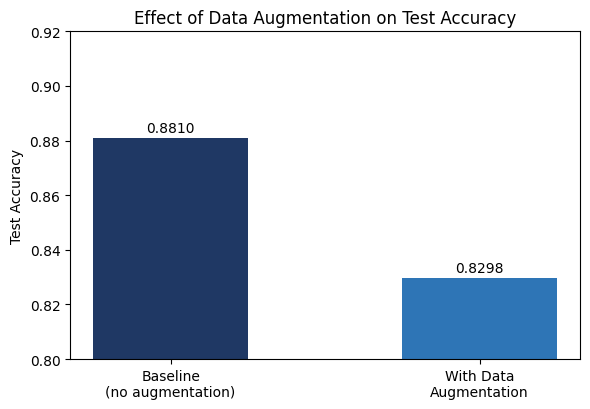

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.2))
labels_ = ["Baseline\n(no augmentation)", "With Data\nAugmentation"]
vals = [test_acc, aug_test_acc]
bars = ax.bar(labels_, vals, color=["#1F3864", "#2E75B6"], width=0.5)
ax.set_ylabel("Test Accuracy"); ax.set_ylim(0.80, 0.92)
ax.set_title("Effect of Data Augmentation on Test Accuracy")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()

**Augmentation made this model *worse*** (82.2% vs. 87.9%), not better. This is an important and counter-intuitive-looking but explainable result: rotation/shift/zoom augmentations assume the model can tolerate small spatial perturbations — a property convolutional networks get "for free" via shared, spatially-local filters. A flattened feedforward network has no such inductive bias: every pixel position is an independent input feature, so shifting or rotating the image scrambles which input neuron sees which part of the garment, effectively adding noise the model cannot generalize across in the same (shorter, 10-epoch) training budget. **Takeaway:** for plain MLP architectures on image data, geometric data augmentation should be used cautiously — it is far more reliably beneficial once convolutional (spatially-aware) layers are introduced.

## 6. Application Demonstration

### Hypothetical deployment: automated tagging for an online fashion retail catalog

A retailer with a constant stream of new product photos (from suppliers, returns processing, or user-generated marketplace listings) needs every image auto-tagged by garment category before it can be indexed, search-filtered, or routed to the right merchandising team. A model in this family is a reasonable fit for a **first-pass triage classifier**:

* **Throughput / real-time needs:** the trained network has ~235K parameters and runs inference on a single 28×28 image in well under a millisecond on CPU, so it comfortably supports both real-time tagging-on-upload and large nightly batch reprocessing of the catalog backlog
* **Integration:** the model would sit behind a lightweight inference API, called from the existing image-ingestion pipeline; outputs (predicted category + confidence) could auto-approve high-confidence tags and route low-confidence images to a human reviewer queue
* **Operational caveats:**
  - **Resolution & domain shift:** the model was trained on clean, centered, background-removed 28×28 grayscale product shots. Real marketplace photos (cluttered backgrounds, color, varying angles, higher resolution) would need preprocessing (cropping/segmentation, resizing, grayscale conversion) or, more robustly, retraining on in-domain photos — performance on out-of-domain images would likely be substantially worse than the 87.9% test accuracy measured here.
  - **The Shirt/T-shirt/Coat confusion is a real product risk:** miscategorizing a dress shirt as a coat could route it to the wrong merchandising category or break a customer's search filter. A production system would likely want a confidence threshold with human-in-the-loop review for the categories shown to be weakest here (Section 4.1), and/or a more capable model for exactly the classes this MLP struggles with


## 7. Conclusion

A simple feedforward neural network (two hidden Dense layers, ReLU + softmax, Adam optimizer) reaches **87.9% test accuracy** (macro F1 0.877) on Fashion-MNIST after only 15 epochs of training — a strong result for an architecture that discards all spatial structure in the image by flattening it to a 784-length vector. The architecture-comparison experiment showed accuracy is largely capacity-saturated for this representation: adding a third hidden layer and ~2.4x the parameters produced no improvement, and switching optimizers (RMSprop) was also neutral
**Future work / potential improvements:**
* **Convolutional layers** are the most promising next step: a small CNN would be expected to both raise the accuracy ceiling beyond ~88% and finally benefit from the geometric data augmentation that hurt the plain MLP here.
* **Targeted handling of the Shirt/T-shirt/Coat/Pullover confusion** — e.g., a second-stage classifier specialized on just those four classes, or additional training data emphasizing their distinguishing features (collar shape, sleeve length)


In [15]:
readme_content = '''# Fashion-MNIST Feedforward Neural Network

A simple feedforward (fully-connected) neural network built, trained, and evaluated on the
[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset using TensorFlow/Keras,
as a practical introduction to applying neural networks to image classification.

## Project overview

| | |
|---|---|
| **Dataset** | Fashion-MNIST — 70,000 grayscale 28×28 images, 10 clothing categories |
| **Model** | Feedforward MLP: `Flatten → Dense(256, ReLU) → Dropout → Dense(128, ReLU) → Dropout → Dense(10, Softmax)` |
| **Training** | Adam optimizer, categorical cross-entropy, 15 epochs, batch size 64 |
| **Test accuracy** | **87.9%** (macro F1: 0.877) |
| **Notebook** | [`fashion_mnist_feedforward_nn.ipynb`](./fashion_mnist_feedforward_nn.ipynb) |
| **Report** | [`report.pdf`](./report.pdf) (2-page summary) |

## What's in this repo

```text
.
├── fashion_mnist_feedforward_nn.ipynb   # Main notebook: data loading, model, training, evaluation, experiments
├── report.pdf / report.docx             # 2-page written report (methodology, results, discussion, conclusion)
├── artifacts/                           # Saved figures (sample grid, training curves, confusion matrix, etc.)
└── README.md
```

## What the notebook covers

1. **Dataset preparation** — loads Fashion-MNIST via `keras.datasets` (with an automatic fallback
   to downloading the official files directly from the Zalando Research GitHub repo if the default
   Keras dataset host isn't reachable), then visualizes one example from each of the 10 classes.
2. **Preprocessing** — normalizes pixel values to `[0, 1]` and one-hot encodes labels.
3. **Model & training** — builds and trains the feedforward network described above, with training/validation loss & accuracy curves.
4. **Evaluation** — test accuracy, precision/recall/F1 (macro & weighted), a full `sklearn` classification report, and a confusion matrix heatmap.
5. **Experiments**
   - **Architecture comparison**: 1-hidden vs. 2-hidden (baseline) vs. 3-hidden layer networks, and Adam vs. RMSprop.
   - **Data augmentation**: rotation/shift/zoom/flip via `ImageDataGenerator`, compared against the non-augmented baseline.
6. **Application demonstration** — a discussion of deploying this model for automated tagging in an online fashion retail catalog, including scalability, real-time processing, integration, and operational risks.
7. **Conclusion** — summary of findings and suggested future work (notably: moving to a CNN architecture).

## Key results

| Experiment | Test Accuracy |
|---|---|
| Baseline (2 hidden layers, Adam, 15 epochs) | **0.8794** |
| 1 hidden layer (Adam, 10 epochs) | 0.8718 |
| 3 hidden layers (Adam, 10 epochs) | 0.8781 |
| 2 hidden layers + RMSprop (10 epochs) | 0.8733 |
| 2 hidden layers + data augmentation (10 epochs) | 0.8216 |

The weakest class is **Shirt** (recall 0.544), frequently confused with T-shirt/top, Pullover, and Coat —
a known, well-documented difficulty in Fashion-MNIST stemming from how visually similar upper-body
garments are at 28×28 grayscale resolution. Data augmentation *reduced* accuracy for this architecture,
illustrating that geometric augmentation benefits convolutional (spatially-aware) networks far more
than flattened feedforward ones.

## Setup instructions

### Run in Google Colab (recommended)
1. Upload `fashion_mnist_feedforward_nn.ipynb` to [Google Colab](https://colab.research.google.com) (File → Upload notebook), or open it directly from this GitHub repo via Colab's "Open notebook → GitHub" tab.
2. Run all cells (Runtime → Run all). No setup is required — Colab already has TensorFlow, scikit-learn, and matplotlib installed, and Fashion-MNIST will load directly via `keras.datasets`.

### Run locally
```bash
git clone <this-repo-url>
cd <repo-folder>
python3 -m venv venv && source venv/bin/activate
pip install tensorflow scikit-learn matplotlib seaborn numpy jupyter
jupyter notebook fashion_mnist_feedforward_nn.ipynb
```

## Requirements
- Python 3.9+
- tensorflow >= 2.15
- scikit-learn
- matplotlib, seaborn
- numpy
- jupyter / jupyterlab (to run the notebook interactively)

## License
This project is for educational purposes. Fashion-MNIST is released by Zalando Research under the
MIT License — see the [original repository](https://github.com/zalandoresearch/fashion-mnist) for details.
'''

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md written:", len(readme_content), "characters")

README.md written: 4366 characters


In [16]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 99 (delta 29), reused 74 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 3.81 MiB | 16.34 MiB/s, done.
Resolving deltas: 100% (29/29), done.
